# Model experiments: Feature Extraction vs Full Fine-tuning vs LoRA vs QLoRA

This notebook keeps the model code visible in one place. Run `Preprocessing.ipynb` first so the processed Rotten Tomatoes files exist under `Data/processed/`.

Recommended flow:
1. Run setup cells.
2. Review the four method sections or run any single-method cell if needed.
3. Run the final all-methods cell.
4. Review the final summary table and comparison plots.


## 1. Imports and paths

In [1]:
from pathlib import Path
from dataclasses import dataclass
from inspect import signature
import importlib.util
import json
import random
import time
import traceback

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset, DatasetDict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebook" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "Data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "Output"
FIGURES_DIR = OUTPUT_DIR / "figures"
METRICS_DIR = OUTPUT_DIR / "metrics"
RESULTS_DIR = OUTPUT_DIR / "results"
WEIGHTS_DIR = OUTPUT_DIR / "model_weights"

for path in [FIGURES_DIR, METRICS_DIR, RESULTS_DIR, WEIGHTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT

c:\Users\mohma\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


WindowsPath('c:/my/Projectes/DeepLearning/Bert-LORA-QLORA-imdb')

## 2. Experiment config

Start with a small `SAMPLE_SIZE` to test everything. Set `SAMPLE_SIZE = None` for the full Rotten Tomatoes splits.

In [2]:
MODEL_NAME = "bert-base-uncased"
RUN_LABEL = "notebook"
SEED = 42
MAX_LENGTH = 128
EPOCHS = 6
SAMPLE_SIZE = None  # Use None for full data.

COMMON_BATCH_SIZE = 4  # Increase to 8 if GPU memory allows.
FEATURE_EXTRACTION_LR = 1e-3
FULL_FINETUNE_LR = 2e-5
LORA_LR = 2e-4
QLORA_LR = 2e-4

LORA_R = 16
LORA_ALPHA = 16
LORA_DROPOUT = 0.1

USE_FP16 = False
DEVICE_INFO = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
DEVICE_INFO

'NVIDIA GeForce RTX 3050 Laptop GPU'

## 3. Data loading and tokenization

In [3]:
def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def load_processed_splits(sample_size: int | None = SAMPLE_SIZE, seed: int = SEED) -> DatasetDict:
    paths = {
        "train": DATA_DIR / "train.parquet",
        "validation": DATA_DIR / "validation.parquet",
        "test": DATA_DIR / "test.parquet",
    }
    missing = [str(path) for path in paths.values() if not path.exists()]
    if missing:
        raise FileNotFoundError(f"Run Notebook/Preprocessing.ipynb first. Missing files: {missing}")

    frames = {}
    for split, path in paths.items():
        df = pd.read_parquet(path)[["text", "label"]].dropna()
        df["text"] = df["text"].astype(str)
        df["label"] = df["label"].astype(int)
        if sample_size:
            per_class = min(sample_size // 2, df["label"].value_counts().min())
            df = (
                df.groupby("label", group_keys=False)
                .sample(n=per_class, random_state=seed)
                .sample(frac=1, random_state=seed)
                .reset_index(drop=True)
            )
        frames[split] = Dataset.from_pandas(df, preserve_index=False)
    return DatasetDict(frames)


def tokenize_dataset(sample_size: int | None = SAMPLE_SIZE, max_length: int = MAX_LENGTH):
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    dataset = load_processed_splits(sample_size=sample_size)

    def tokenize_batch(batch):
        return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=max_length)

    tokenized = dataset.map(tokenize_batch, batched=True, remove_columns=["text"])
    for split in tokenized:
        tokenized[split] = tokenized[split].rename_column("label", "labels")
    return tokenized, tokenizer


raw_preview = load_processed_splits(sample_size=5)
raw_preview

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 4
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 4
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 4
    })
})

## 4. Metrics and saving helpers

In [4]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
    }


def count_parameters(model):
    if hasattr(model, "get_nb_trainable_parameters"):
        trainable, total = model.get_nb_trainable_parameters()
    else:
        total = sum(p.numel() for p in model.parameters())
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {
        "total_parameters": int(total),
        "trainable_parameters": int(trainable),
        "trainable_percent": round((trainable / total) * 100, 4),
    }


def reset_gpu_memory():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()


def peak_gpu_memory_mb():
    if not torch.cuda.is_available():
        return None
    return round(torch.cuda.max_memory_allocated() / (1024 ** 2), 2)


def save_metrics(run_name: str, payload: dict):
    metrics_path = METRICS_DIR / f"{run_name}_metrics.json"
    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)
    return metrics_path


SUMMARY_COLUMNS = [
    "run_name", "method", "seed", "status",
    "dataset_train_rows", "dataset_validation_rows", "dataset_test_rows",
    "sample_size", "epochs", "batch_size", "learning_rate", "max_length",
    "accuracy", "precision", "recall", "f1",
    "training_time_seconds", "peak_gpu_memory_mb", "model_dir",
    "total_parameters", "trainable_parameters", "trainable_percent", "error_file",
]


def append_summary(row: dict):
    summary_path = RESULTS_DIR / "summary_results.csv"
    new_row = pd.DataFrame([row]).reindex(columns=SUMMARY_COLUMNS)
    if summary_path.exists():
        existing = pd.read_csv(summary_path).reindex(columns=SUMMARY_COLUMNS)
        new_row = pd.concat([existing, new_row], ignore_index=True)
    new_row.to_csv(summary_path, index=False)
    return summary_path

## 5. Shared Trainer runner

In [5]:
@dataclass
class RunConfig:
    method: str
    batch_size: int
    learning_rate: float
    epochs: float = EPOCHS
    seed: int = SEED
    max_length: int = MAX_LENGTH
    sample_size: int | None = SAMPLE_SIZE
    fp16: bool = USE_FP16


def training_args(config: RunConfig, run_dir: Path):
    args = {
        "output_dir": str(run_dir),
        "learning_rate": config.learning_rate,
        "per_device_train_batch_size": config.batch_size,
        "per_device_eval_batch_size": config.batch_size,
        "num_train_epochs": config.epochs,
        "weight_decay": 0.01,
        "logging_strategy": "steps",
        "logging_steps": 0.1,  # Log every 10% of total training steps.
        "save_strategy": "epoch",
        "save_total_limit": 1,
        "report_to": "none",
        "fp16": bool(config.fp16),
    }
    if "eval_strategy" in signature(TrainingArguments.__init__).parameters:
        args["eval_strategy"] = "epoch"
    else:
        args["evaluation_strategy"] = "epoch"
    return TrainingArguments(**args)


def train_and_evaluate(model, tokenizer, config: RunConfig):
    set_seed(config.seed)
    run_name = f"{RUN_LABEL}_{config.method}_seed_{config.seed}"
    run_dir = WEIGHTS_DIR / run_name
    tokenized, tokenizer = tokenize_dataset(sample_size=config.sample_size, max_length=config.max_length)
    params = count_parameters(model)
    print(f"{config.method} parameter counts:", params)

    trainer = Trainer(
        model=model,
        args=training_args(config, run_dir),
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["validation"],
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
    )

    reset_gpu_memory()
    start = time.perf_counter()
    train_result = trainer.train()
    training_time = round(time.perf_counter() - start, 2)
    test_metrics = trainer.evaluate(tokenized["test"])

    final_dir = run_dir / "final"
    trainer.save_model(str(final_dir))
    tokenizer.save_pretrained(str(final_dir))

    row = {
        "run_name": run_name,
        "method": config.method,
        "seed": config.seed,
        "status": "ok",
        "dataset_train_rows": len(tokenized["train"]),
        "dataset_validation_rows": len(tokenized["validation"]),
        "dataset_test_rows": len(tokenized["test"]),
        "sample_size": config.sample_size,
        "epochs": config.epochs,
        "batch_size": config.batch_size,
        "learning_rate": config.learning_rate,
        "max_length": config.max_length,
        "accuracy": test_metrics.get("eval_accuracy"),
        "precision": test_metrics.get("eval_precision"),
        "recall": test_metrics.get("eval_recall"),
        "f1": test_metrics.get("eval_f1"),
        "training_time_seconds": training_time,
        "peak_gpu_memory_mb": peak_gpu_memory_mb(),
        "model_dir": str(final_dir),
        **params,
    }
    save_metrics(run_name, {"config": config.__dict__, "train": train_result.metrics, "test": test_metrics, "summary": row})
    append_summary(row)
    return row

## 6. Feature Extraction only

BERT is frozen. Only the classification head is trained.

In [6]:
def build_feature_extraction_model():
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
    for param in model.bert.parameters():
        param.requires_grad = False
    return model


def run_feature_extraction():
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = build_feature_extraction_model()
    config = RunConfig(method="feature_extraction", batch_size=COMMON_BATCH_SIZE, learning_rate=FEATURE_EXTRACTION_LR)
    return train_and_evaluate(model, tokenizer, config)


# Optional single-method run:
# feature_result = run_feature_extraction()
# pd.DataFrame([feature_result]).T

## 7. Full Fine-tuning only

All BERT parameters are trainable.

In [7]:
def build_finetune_model():
    return AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)


def run_finetune():
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = build_finetune_model()
    config = RunConfig(method="finetune", batch_size=COMMON_BATCH_SIZE, learning_rate=FULL_FINETUNE_LR)
    return train_and_evaluate(model, tokenizer, config)


# Optional single-method run:
# finetune_result = run_finetune()
# pd.DataFrame([finetune_result]).T

## 8. LoRA only

BERT is frozen and small LoRA adapters are trained on attention `query` and `value` modules.

In [8]:
def build_lora_model():
    from peft import LoraConfig, TaskType, get_peft_model

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        target_modules=["query", "value"],
        modules_to_save=["classifier"],
    )
    return get_peft_model(model, lora_config)


def run_lora():
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = build_lora_model()
    config = RunConfig(method="lora", batch_size=COMMON_BATCH_SIZE, learning_rate=LORA_LR)
    return train_and_evaluate(model, tokenizer, config)


# Optional single-method run:
# lora_result = run_lora()
# pd.DataFrame([lora_result]).T

## 9. QLoRA only

This needs a working CUDA + bitsandbytes setup. If it fails on native Windows, run this cell on WSL2, Linux, Colab, or Kaggle.

In [9]:
def build_qlora_model():
    if not torch.cuda.is_available():
        raise RuntimeError("QLoRA requires CUDA.")
    if importlib.util.find_spec("bitsandbytes") is None:
        raise RuntimeError("bitsandbytes is not installed.")

    from peft import LoraConfig, TaskType, get_peft_model, prepare_model_for_kbit_training
    from transformers import BitsAndBytesConfig

    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float32,
    )
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2,
        quantization_config=quant_config,
    )
    model = prepare_model_for_kbit_training(model)
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        target_modules=["query", "value"],
        modules_to_save=["classifier"],
    )
    return get_peft_model(model, lora_config)


def run_qlora():
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = build_qlora_model()
    config = RunConfig(method="qlora", batch_size=COMMON_BATCH_SIZE, learning_rate=QLORA_LR)
    return train_and_evaluate(model, tokenizer, config)


# Optional single-method run:
# try:
#     qlora_result = run_qlora()
# except Exception as exc:
#     error_path = METRICS_DIR / f"{RUN_LABEL}_qlora_error_seed_{SEED}.txt"
#     error_path.write_text(traceback.format_exc(), encoding="utf-8")
#     qlora_result = {"run_name": f"{RUN_LABEL}_qlora_seed_{SEED}", "method": "qlora", "seed": SEED, "status": "failed", "error_file": str(error_path), "error": str(exc)}
#     append_summary(qlora_result)
#     print("QLoRA failed cleanly. Check:", error_path)
# pd.DataFrame([qlora_result]).T

## 10. Run everything together

This final cell runs Feature Extraction, Full Fine-tuning, LoRA, then QLoRA in one pass. Keep `SAMPLE_SIZE` small until the flow is stable, then set it to `None` and increase `EPOCHS`.

In [10]:
all_results = []

for name, runner in [
    ("feature_extraction", run_feature_extraction),
    ("finetune", run_finetune),
    ("lora", run_lora),
    ("qlora", run_qlora),
]:
    print(f"\n===== Running {name} =====")
    try:
        result = runner()
    except Exception as exc:
        error_path = METRICS_DIR / f"{RUN_LABEL}_{name}_all_error_seed_{SEED}.txt"
        error_path.write_text(traceback.format_exc(), encoding="utf-8")
        result = {"run_name": f"{RUN_LABEL}_{name}_seed_{SEED}", "method": name, "seed": SEED, "status": "failed", "error_file": str(error_path), "error": str(exc)}
        append_summary(result)
        print(f"{name} failed cleanly. Check: {error_path}")
    all_results.append(result)

pd.DataFrame(all_results)


===== Running feature_extraction =====


c:\Users\mohma\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Map: 100%|██████████| 1066/1066 [00:00<00:00, 20900.54 examples/s]


feature_extraction parameter counts: {'total_parameters': 109483778, 'trainable_parameters': 1538, 'trainable_percent': 0.0014}


  0%|          | 0/12798 [00:00<?, ?it/s]c:\Users\mohma\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\models\bert\modeling_bert.py:439: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
 10%|█         | 1284/12798 [00:44<06:39, 28.83it/s]

{'loss': 0.6622, 'grad_norm': 3.0046985149383545, 'learning_rate': 0.0008999843725582122, 'epoch': 0.6}


...

{'eval_loss': 0.5700161457061768, 'eval_accuracy': 0.8592870544090057, 'eval_precision': 0.852670349907919, 'eval_recall': 0.8686679174484052, 'eval_f1': 0.8605947955390335, 'eval_runtime': 10.0079, 'eval_samples_per_second': 106.516, 'eval_steps_per_second': 26.679, 'epoch': 6.0}


100%|██████████| 12798/12798 [27:04<00:00,  7.88it/s]


{'train_runtime': 1624.5784, 'train_samples_per_second': 31.504, 'train_steps_per_second': 7.878, 'train_loss': 0.3397001113569686, 'epoch': 6.0}


100%|██████████| 267/267 [00:10<00:00, 26.61it/s]
C:\Users\mohma\AppData\Local\Temp\ipykernel_34788\3928413847.py:59: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  new_row = pd.concat([existing, new_row], ignore_index=True)


,run_name,method,seed,status,dataset_train_rows,dataset_validation_rows,dataset_test_rows,sample_size,epochs,batch_size,...,accuracy,precision,recall,f1,training_time_seconds,peak_gpu_memory_mb,model_dir,total_parameters,trainable_parameters,trainable_percent
0,notebook_feature_extraction_seed_42,feature_extraction,42,ok,8530,1066,1066,None,6,4,...,0.765478,0.751332,0.793621,0.771898,494.44,453.29,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,109483778,1538,0.0014
1,notebook_finetune_seed_42,finetune,42,ok,8530,1066,1066,None,6,4,...,0.850844,0.847584,0.855535,0.851541,1934.51,2114.45,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,109483778,109483778,100.0000
2,notebook_lora_seed_42,lora,42,ok,8530,1066,1066,None,6,4,...,0.847092,0.855769,0.834897,0.845204,1006.80,703.39,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,110075140,591362,0.5372
3,notebook_qlora_seed_42,qlora,42,ok,8530,1066,1066,None,6,4,...,0.848968,0.857692,0.836773,0.847104,1624.76,224.82,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,110075140,591362,0.5372


## 11. Compare current results

In [11]:
summary_path = RESULTS_DIR / "summary_results.csv"
summary = pd.read_csv(summary_path).reindex(columns=SUMMARY_COLUMNS)
summary = summary[summary["method"].isin(["feature_extraction", "finetune", "lora", "qlora"])]
summary.tail(10)

,run_name,method,seed,status,dataset_train_rows,dataset_validation_rows,dataset_test_rows,sample_size,epochs,batch_size,...,precision,recall,f1,training_time_seconds,peak_gpu_memory_mb,model_dir,total_parameters,trainable_parameters,trainable_percent,error_file
24,notebook_qlora_seed_42,qlora,42,ok,5000.0,1066.0,1066.0,5000.0,3.0,2.0,...,0.836576,0.806754,0.821394,1105.50,200.02,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,110075140.0,591362.0,0.5372,NaN
26,notebook_lora_seed_42,lora,42,ok,5000.0,1066.0,1066.0,5000.0,3.0,2.0,...,0.834601,0.823640,0.829084,427.77,565.33,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,110075140.0,591362.0,0.5372,NaN
27,notebook_feature_extraction_seed_42,feature_extraction,42,ok,3000.0,1066.0,1066.0,3000.0,5.0,4.0,...,0.716007,0.780488,0.746858,176.91,871.58,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,109483778.0,1538.0,0.0014,NaN
28,notebook_finetune_seed_42,finetune,42,ok,3000.0,1066.0,1066.0,3000.0,5.0,4.0,...,0.852490,0.834897,0.843602,743.69,2531.98,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,109483778.0,109483778.0,100.0000,NaN
29,notebook_lora_seed_42,lora,42,ok,3000.0,1066.0,1066.0,3000.0,5.0,4.0,...,0.844402,0.834897,0.839623,328.79,1129.18,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,110075140.0,591362.0,0.5372,NaN
30,notebook_qlora_seed_42,qlora,42,ok,3000.0,1066.0,1066.0,3000.0,5.0,4.0,...,0.845149,0.849906,0.847521,515.92,659.86,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,110075140.0,591362.0,0.5372,NaN
31,notebook_feature_extraction_seed_42,feature_extraction,42,ok,8530.0,1066.0,1066.0,NaN,6.0,4.0,...,0.751332,0.793621,0.771898,494.44,453.29,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,109483778.0,1538.0,0.0014,NaN
32,notebook_finetune_seed_42,finetune,42,ok,8530.0,1066.0,1066.0,NaN,6.0,4.0,...,0.847584,0.855535,0.851541,1934.51,2114.45,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,109483778.0,109483778.0,100.0000,NaN
33,notebook_lora_seed_42,lora,42,ok,8530.0,1066.0,1066.0,NaN,6.0,4.0,...,0.855769,0.834897,0.845204,1006.80,703.39,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,110075140.0,591362.0,0.5372,NaN
34,notebook_qlora_seed_42,qlora,42,ok,8530.0,1066.0,1066.0,NaN,6.0,4.0,...,0.857692,0.836773,0.847104,1624.76,224.82,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,110075140.0,591362.0,0.5372,NaN


,method,dataset_train_rows,accuracy,precision,recall,f1,training_time_seconds,peak_gpu_memory_mb,total_parameters,trainable_parameters
31,feature_extraction,8530.0,0.765478,0.751332,0.793621,0.771898,494.44,453.29,109483778.0,1538.0
32,finetune,8530.0,0.850844,0.847584,0.855535,0.851541,1934.51,2114.45,109483778.0,109483778.0
33,lora,8530.0,0.847092,0.855769,0.834897,0.845204,1006.80,703.39,110075140.0,591362.0
34,qlora,8530.0,0.848968,0.857692,0.836773,0.847104,1624.76,224.82,110075140.0,591362.0


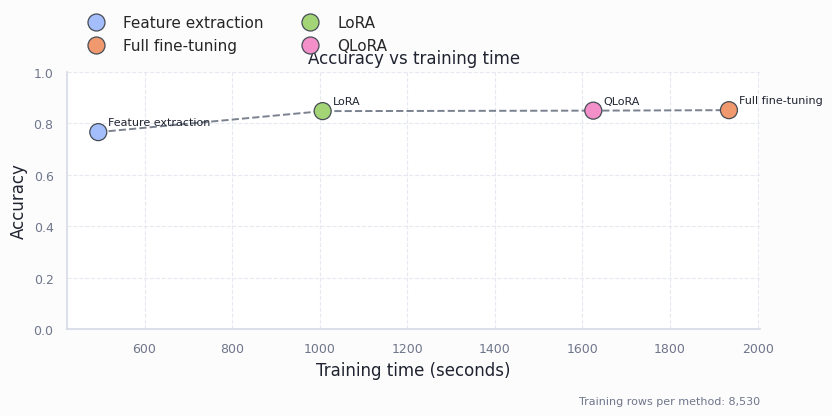

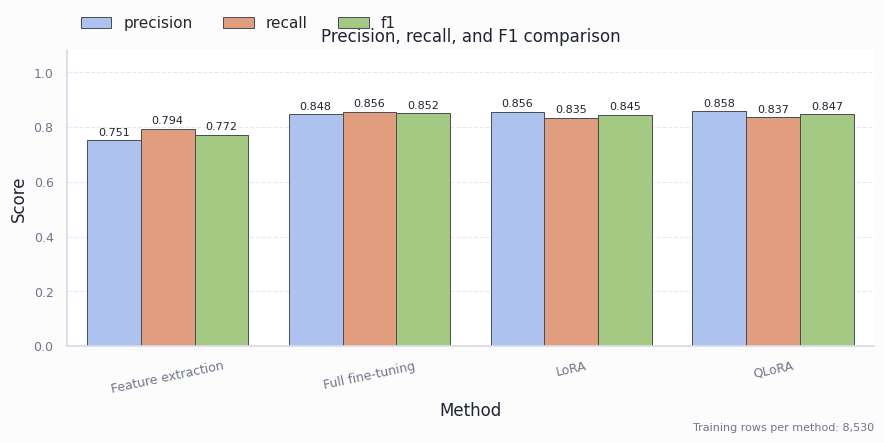

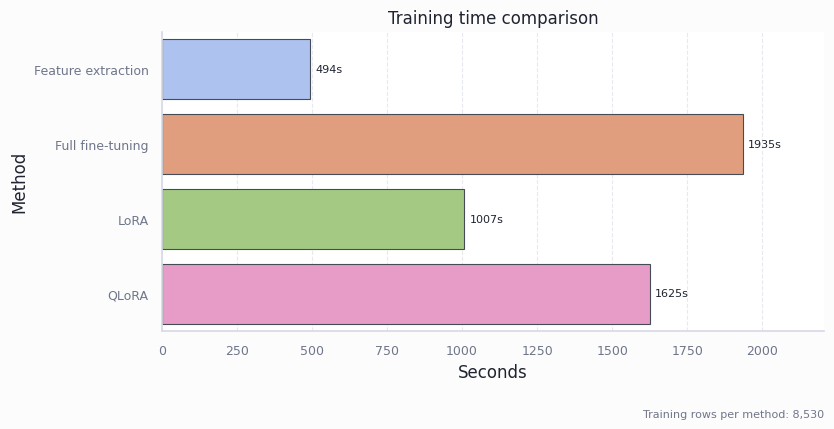

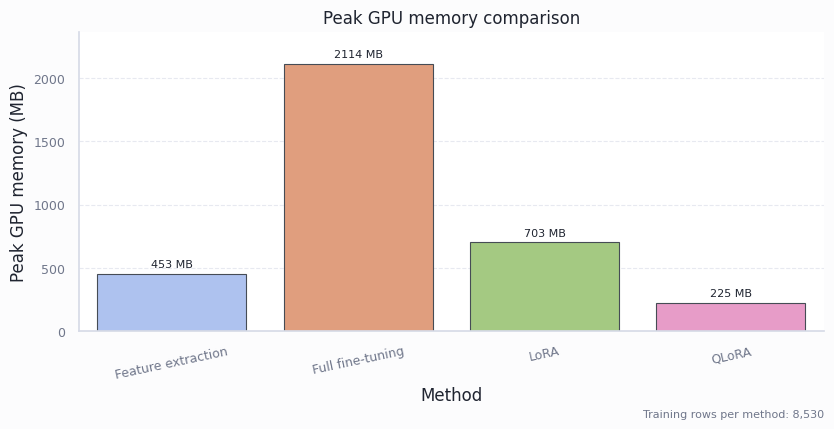

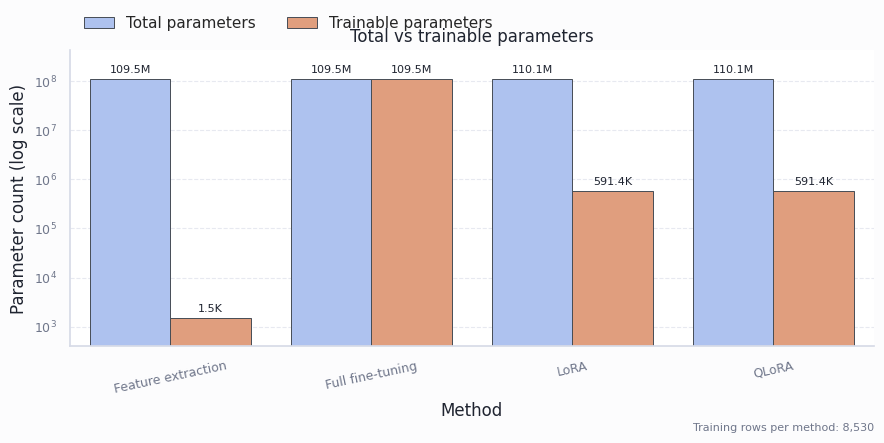

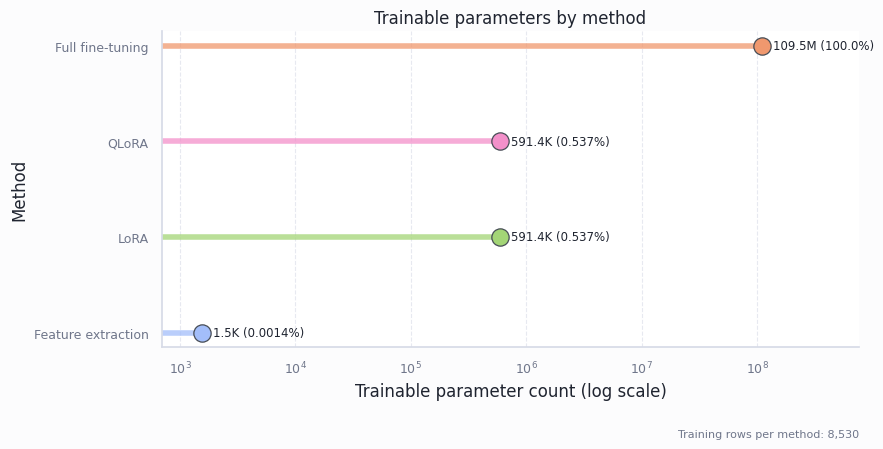

In [12]:
METHOD_ORDER = ["feature_extraction", "finetune", "lora", "qlora"]
METHOD_LABELS = {
    "feature_extraction": "Feature extraction",
    "finetune": "Full fine-tuning",
    "lora": "LoRA",
    "qlora": "QLoRA",
}
METHOD_PALETTE = {
    "Feature extraction": "#A3BEFA",
    "Full fine-tuning": "#F0986E",
    "LoRA": "#A3D576",
    "QLoRA": "#F390CA",
}
METRIC_PALETTE = {"precision": "#A3BEFA", "recall": "#F0986E", "f1": "#A3D576"}
PARAM_PALETTE = {"Total parameters": "#A3BEFA", "Trainable parameters": "#F0986E"}
SURFACE_COLOR = "#FCFCFD"
PANEL_COLOR = "#FFFFFF"
INK_COLOR = "#1F2430"
MUTED_COLOR = "#6F768A"
GRID_COLOR = "#E6E8F0"
EDGE_COLOR = "#464C55"

sns.set_theme(
    style="whitegrid",
    rc={
        "figure.facecolor": SURFACE_COLOR,
        "axes.facecolor": PANEL_COLOR,
        "axes.edgecolor": "#D7DBE7",
        "axes.labelcolor": INK_COLOR,
        "axes.titlecolor": INK_COLOR,
        "xtick.color": MUTED_COLOR,
        "ytick.color": MUTED_COLOR,
        "grid.color": GRID_COLOR,
        "grid.linestyle": "--",
        "grid.linewidth": 0.8,
        "font.family": "DejaVu Sans",
    },
)


def latest_successful_results(summary: pd.DataFrame) -> pd.DataFrame:
    status = summary["status"].fillna("ok") if "status" in summary.columns else pd.Series("ok", index=summary.index)
    ok = summary[status.eq("ok")].copy()
    ok = ok[ok["method"].isin(METHOD_ORDER)]
    latest = ok.groupby("method", as_index=False).tail(1).copy()
    if "trainable_percent" not in latest.columns:
        latest["trainable_percent"] = (latest["trainable_parameters"] / latest["total_parameters"]) * 100
    latest["method"] = pd.Categorical(latest["method"], categories=METHOD_ORDER, ordered=True)
    latest = latest.sort_values("method")
    latest["method_label"] = latest["method"].astype(str).map(METHOD_LABELS)
    latest["method_label"] = pd.Categorical(latest["method_label"], categories=list(METHOD_PALETTE), ordered=True)
    return latest


def style_axis(ax, *, grid_axis="y"):
    ax.set_axisbelow(True)
    if grid_axis == "both":
        ax.grid(True, axis="both", linestyle="--", linewidth=0.8, color=GRID_COLOR, alpha=0.95)
    else:
        ax.grid(True, axis=grid_axis, linestyle="--", linewidth=0.8, color=GRID_COLOR, alpha=0.95)
        ax.grid(False, axis="x" if grid_axis == "y" else "y")
    sns.despine(ax=ax)
    ax.tick_params(colors=MUTED_COLOR, labelsize=9)
    ax.xaxis.label.set_color(INK_COLOR)
    ax.yaxis.label.set_color(INK_COLOR)
    ax.title.set_color(INK_COLOR)
    return ax


def compact_value(value, *, kind="number"):
    if pd.isna(value):
        return ""
    value = float(value)
    if kind == "score":
        return f"{value:.3f}"
    if kind == "seconds":
        return f"{value:.0f}s"
    if kind == "memory":
        return f"{value:.0f} MB"
    if kind == "percent":
        return f"{value:.2f}%"
    abs_value = abs(value)
    if abs_value >= 1_000_000_000:
        return f"{value / 1_000_000_000:.1f}B"
    if abs_value >= 1_000_000:
        return f"{value / 1_000_000:.1f}M"
    if abs_value >= 1_000:
        return f"{value / 1_000:.1f}K"
    return f"{value:.0f}"


def add_bar_labels(ax, *, orientation="v", kind="number", padding=3):
    for container in ax.containers:
        labels = []
        for patch in container.patches:
            value = patch.get_height() if orientation == "v" else patch.get_width()
            labels.append(compact_value(value, kind=kind) if pd.notna(value) else "")
        ax.bar_label(container, labels=labels, padding=padding, fontsize=8, color=INK_COLOR)
    if orientation == "v":
        ax.margins(y=0.12)
    else:
        ax.margins(x=0.14)


def training_rows_note(data: pd.DataFrame) -> str:
    if "dataset_train_rows" not in data.columns or data["dataset_train_rows"].dropna().empty:
        return "Training rows: not recorded"
    train_rows = data["dataset_train_rows"].dropna().astype(int)
    if train_rows.nunique() == 1:
        return f"Training rows per method: {train_rows.iloc[0]:,}"
    parts = [f"{row['method_label']}: {int(row['dataset_train_rows']):,}" for _, row in data.dropna(subset=["dataset_train_rows"]).iterrows()]
    return "Training rows: " + " | ".join(parts)


def add_training_rows_note(ax, data: pd.DataFrame):
    ax.text(
        1.0,
        -0.26,
        training_rows_note(data),
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8,
        color=MUTED_COLOR,
    )


def save_and_show(filename: str):
    path = FIGURES_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight", facecolor=SURFACE_COLOR)
    plt.show()
    return path


latest = latest_successful_results(summary)
comparison_columns = [
    "method",
    "dataset_train_rows",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "training_time_seconds",
    "peak_gpu_memory_mb",
    "total_parameters",
    "trainable_parameters",
]
display(latest[[col for col in comparison_columns if col in latest.columns]])

# 1) Accuracy against training time for the four methods.
accuracy_time = latest.dropna(subset=["training_time_seconds", "accuracy"]).sort_values("training_time_seconds")
if not accuracy_time.empty:
    fig, ax = plt.subplots(figsize=(8.5, 4.6))
    ax.plot(
        accuracy_time["training_time_seconds"],
        accuracy_time["accuracy"],
        color="#7A828F",
        linewidth=1.4,
        linestyle="--",
        zorder=1,
    )
    sns.scatterplot(
        data=accuracy_time,
        x="training_time_seconds",
        y="accuracy",
        hue="method_label",
        palette=METHOD_PALETTE,
        s=150,
        edgecolor=EDGE_COLOR,
        linewidth=0.9,
        ax=ax,
        zorder=2,
    )
    for _, row in accuracy_time.iterrows():
        ax.annotate(str(row["method_label"]), (row["training_time_seconds"], row["accuracy"]), xytext=(7, 5), textcoords="offset points", fontsize=8, color=INK_COLOR)
    ax.set_title("Accuracy vs training time")
    ax.set_xlabel("Training time (seconds)")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1)
    ax.legend(title="", loc="lower left", bbox_to_anchor=(0, 1.02), ncol=2, frameon=False)
    style_axis(ax, grid_axis="both")
    add_training_rows_note(ax, accuracy_time)
    save_and_show("notebook_accuracy_line_comparison.png")

# 2) Grouped bar chart for Precision, Recall, and F1.
score_cols = ["precision", "recall", "f1"]
scores_long = latest.melt(id_vars="method_label", value_vars=score_cols, var_name="metric", value_name="score")
fig, ax = plt.subplots(figsize=(9, 4.8))
sns.barplot(data=scores_long, x="method_label", y="score", hue="metric", palette=METRIC_PALETTE, edgecolor=EDGE_COLOR, linewidth=0.7, ax=ax)
add_bar_labels(ax, kind="score", padding=2)
ax.set_title("Precision, recall, and F1 comparison")
ax.set_xlabel("Method")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.08)
ax.legend(title="", loc="lower left", bbox_to_anchor=(0, 1.02), ncol=3, frameon=False)
ax.tick_params(axis="x", rotation=12)
style_axis(ax, grid_axis="y")
add_training_rows_note(ax, latest)
save_and_show("notebook_classification_scores_grouped_bar.png")

# 3) Horizontal bar chart for training time.
if latest["training_time_seconds"].notna().any():
    time_plot = latest.dropna(subset=["training_time_seconds"]).sort_values("training_time_seconds", ascending=True)
    fig, ax = plt.subplots(figsize=(8.5, 4.6))
    sns.barplot(data=time_plot, y="method_label", x="training_time_seconds", hue="method_label", palette=METHOD_PALETTE, legend=False, orient="h", edgecolor=EDGE_COLOR, linewidth=0.8, ax=ax)
    add_bar_labels(ax, orientation="h", kind="seconds", padding=4)
    ax.set_title("Training time comparison")
    ax.set_xlabel("Seconds")
    ax.set_ylabel("Method")
    style_axis(ax, grid_axis="x")
    add_training_rows_note(ax, time_plot)
    save_and_show("notebook_training_time_horizontal_bar.png")

# 4) GPU memory bar chart.
if latest["peak_gpu_memory_mb"].notna().any():
    memory_plot = latest.dropna(subset=["peak_gpu_memory_mb"])
    fig, ax = plt.subplots(figsize=(8.5, 4.6))
    sns.barplot(data=memory_plot, x="method_label", y="peak_gpu_memory_mb", hue="method_label", palette=METHOD_PALETTE, legend=False, edgecolor=EDGE_COLOR, linewidth=0.8, ax=ax)
    add_bar_labels(ax, kind="memory", padding=3)
    ax.set_title("Peak GPU memory comparison")
    ax.set_xlabel("Method")
    ax.set_ylabel("Peak GPU memory (MB)")
    ax.tick_params(axis="x", rotation=12)
    style_axis(ax, grid_axis="y")
    add_training_rows_note(ax, memory_plot)
    save_and_show("notebook_gpu_memory_bar.png")

# 5) Total vs trainable parameters, log scale.
param_cols = ["total_parameters", "trainable_parameters"]
params_long = latest.melt(id_vars="method_label", value_vars=param_cols, var_name="parameter_type", value_name="count")
params_long["parameter_type"] = params_long["parameter_type"].map({"total_parameters": "Total parameters", "trainable_parameters": "Trainable parameters"})
fig, ax = plt.subplots(figsize=(9, 4.8))
sns.barplot(data=params_long, x="method_label", y="count", hue="parameter_type", palette=PARAM_PALETTE, edgecolor=EDGE_COLOR, linewidth=0.7, ax=ax)
ax.set_yscale("log")
add_bar_labels(ax, kind="number", padding=3)
ax.set_title("Total vs trainable parameters")
ax.set_xlabel("Method")
ax.set_ylabel("Parameter count (log scale)")
ax.legend(title="", loc="lower left", bbox_to_anchor=(0, 1.02), ncol=2, frameon=False)
ax.tick_params(axis="x", rotation=12)
style_axis(ax, grid_axis="y")
add_training_rows_note(ax, latest)
save_and_show("notebook_parameters_log_bar.png")

# 6) Trainable parameter count on a log scale.
if latest["trainable_parameters"].notna().any():
    trainable_plot = latest.dropna(subset=["trainable_parameters"]).sort_values("trainable_parameters", ascending=True)
    fig, ax = plt.subplots(figsize=(9, 4.8))
    y_positions = range(len(trainable_plot))
    x_start = max(1, trainable_plot["trainable_parameters"].min() * 0.45)

    for y, (_, row) in zip(y_positions, trainable_plot.iterrows()):
        color = METHOD_PALETTE[str(row["method_label"])]
        ax.hlines(y=y, xmin=x_start, xmax=row["trainable_parameters"], color=color, linewidth=4, alpha=0.75)
        ax.scatter(row["trainable_parameters"], y, s=155, color=color, edgecolor=EDGE_COLOR, linewidth=0.9, zorder=3)
        percent = row["trainable_percent"]
        percent_label = f"{percent:.4f}%" if percent < 0.01 else f"{percent:.3f}%" if percent < 1 else f"{percent:.1f}%"
        ax.annotate(
            f"{compact_value(row['trainable_parameters'])} ({percent_label})",
            (row["trainable_parameters"], y),
            xytext=(8, 0),
            textcoords="offset points",
            va="center",
            fontsize=8.5,
            color=INK_COLOR,
        )

    ax.set_xscale("log")
    ax.set_xlim(x_start, trainable_plot["trainable_parameters"].max() * 7)
    ax.set_yticks(list(y_positions), trainable_plot["method_label"].astype(str))
    ax.set_title("Trainable parameters by method")
    ax.set_xlabel("Trainable parameter count (log scale)")
    ax.set_ylabel("Method")
    style_axis(ax, grid_axis="x")
    add_training_rows_note(ax, trainable_plot)
    save_and_show("notebook_trainable_percent_histplot.png")